In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats

In [19]:
df = pd.read_csv("quikr_car.csv")
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [21]:
df.describe()

,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [23]:
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [24]:
df.dropna(inplace=True) 

In [25]:
df.isnull().sum()

name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64

In [26]:
df.describe()

,name,company,year,Price,kms_driven,fuel_type
count,837,837,837,837,837,837
unique,473,25,21,273,256,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,229,117,21,30,440


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 837 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        837 non-null    object
 1   company     837 non-null    object
 2   year        837 non-null    object
 3   Price       837 non-null    object
 4   kms_driven  837 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 45.8+ KB


In [28]:
df['Price'].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [29]:
filtered_df = df[df['Price'] == 'Ask For Price']
filtered_df.shape[0]

21

In [30]:
mask = df['Price'] == "Ask For Price"
df = df[~mask]

In [31]:
df['Price'] = df['Price'].str.replace(',', '').astype(int)

C:\Users\AMRUTA\AppData\Local\Temp\ipykernel_25224\2880342471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = df['Price'].str.replace(',', '').astype(int)


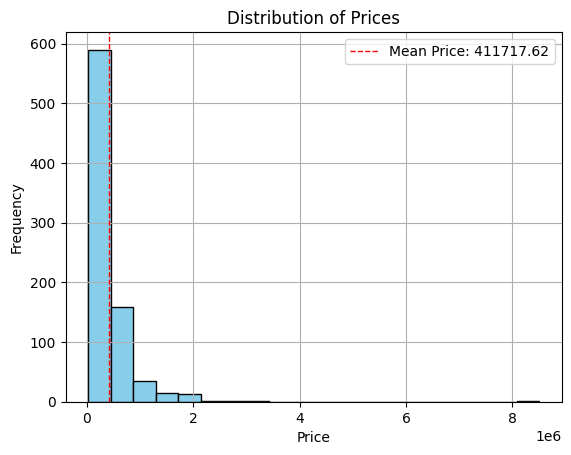

In [32]:
plt.hist(df['Price'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
mean_price = df['Price'].mean()
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=1, label=f'Mean Price: {mean_price:.2f}')
plt.legend()
plt.show()

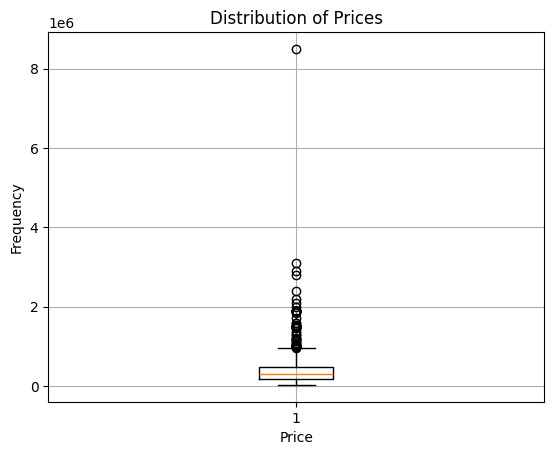

In [33]:
plt.boxplot(df['Price'])
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [34]:
z_scores = stats.zscore(df['Price'])
threshold = 3
df = df[(np.abs(z_scores) < threshold)]

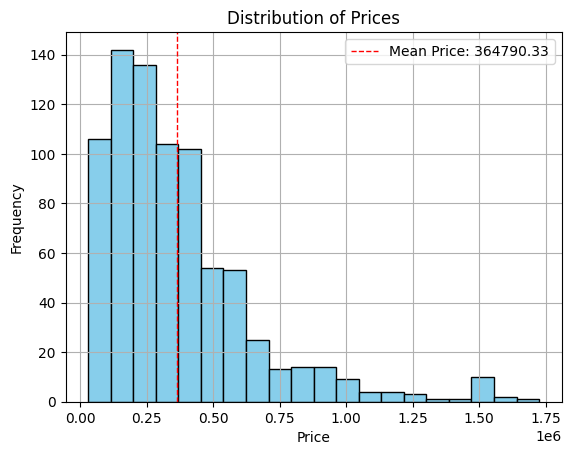

In [35]:
plt.hist(df['Price'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
mean_price = df['Price'].mean()
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=1, label=f'Mean Price: {mean_price:.2f}')
plt.legend()
plt.show()

In [36]:
df.describe()

,Price
count,7.980000e+02
mean,3.647903e+05
std,2.822341e+05
min,3.000000e+04
25%,1.749992e+05
50%,2.900000e+05
75%,4.750000e+05
max,1.725000e+06


In [37]:
df['year'].unique()

array(['2007', '2006', '2014', '2012', '2013', '2016', '2015', '2010',
       '2017', '2008', '2018', '2011', '2019', '2009', '2005', '2000',
       '2003', '2004', '1995', '2002', '2001'], dtype=object)

In [38]:
df['year'] = df['year'].astype(int)
df['kms_driven'] = df['kms_driven'].str.replace('kms', '')
df['kms_driven'] = df['kms_driven'].str.replace(',', '').astype(int)

In [39]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel


C:\Users\AMRUTA\AppData\Local\Temp\ipykernel_25224\942115203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fuel_type', y='Price', data=df, palette='coolwarm')


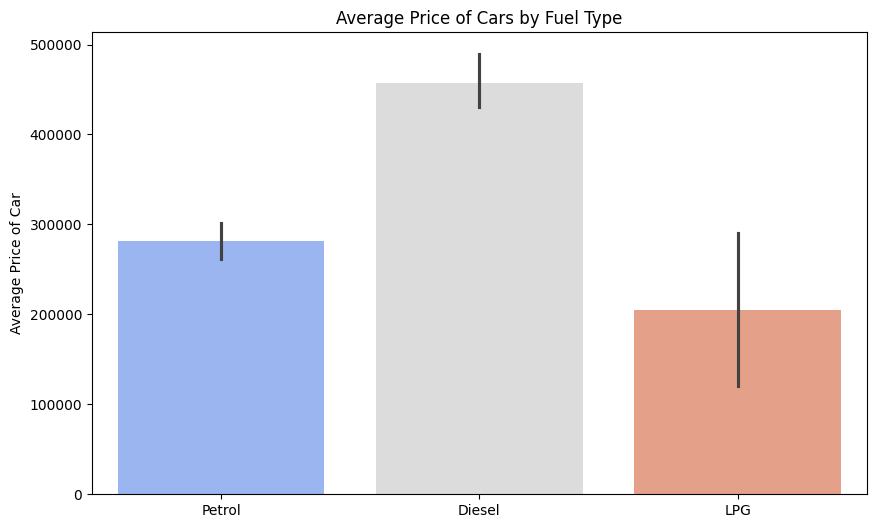

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(x='fuel_type', y='Price', data=df, palette='coolwarm')
plt.title('Average Price of Cars by Fuel Type')
plt.xlabel('')
plt.ylabel('Average Price of Car')
plt.show()

In [41]:
df.groupby('fuel_type')['Price'].mean()

fuel_type
Diesel    457597.513228
LPG       205000.000000
Petrol    281628.763158
Name: Price, dtype: float64

In [42]:
df['fuel_type'].unique()

array(['Petrol', 'Diesel', 'LPG'], dtype=object)

In [43]:
df_encoded = pd.get_dummies(df['fuel_type'], prefix='fuel_type').astype(int)
df = pd.concat([df, df_encoded], axis=1)
df = df.drop('fuel_type', axis=1)

In [44]:
df.head()

,name,company,year,Price,kms_driven,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,0,0,1
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,1,0,0
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,0,0,1
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,1,0,0
6,Ford Figo,Ford,2012,175000,41000,1,0,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 798 entries, 0 to 889
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   name              798 non-null    object
 1   company           798 non-null    object
 2   year              798 non-null    int64 
 3   Price             798 non-null    int64 
 4   kms_driven        798 non-null    int64 
 5   fuel_type_Diesel  798 non-null    int64 
 6   fuel_type_LPG     798 non-null    int64 
 7   fuel_type_Petrol  798 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 56.1+ KB


In [46]:
df1 = df[['year', 'kms_driven', 'fuel_type_Diesel', 'fuel_type_LPG', 'fuel_type_Petrol', 'Price']]

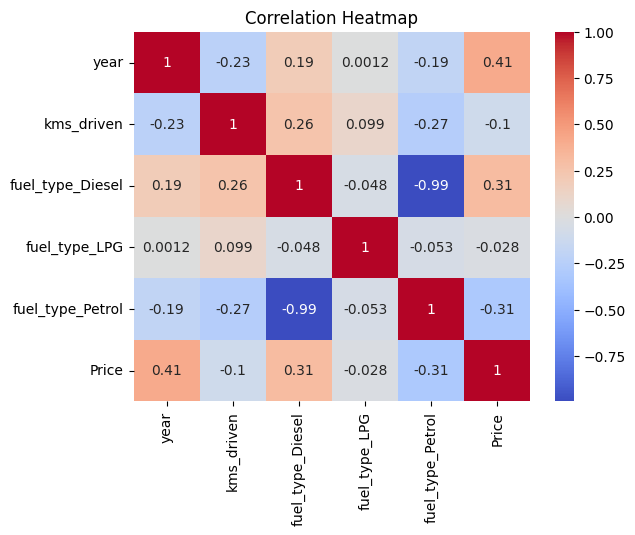

In [47]:
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [48]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Jeep'], dtype=object)

In [49]:
pd.options.display.float_format = '{:.2f}'.format
average_price_company = df.groupby('company')['Price'].mean().sort_values(ascending=False)
average_price_company

company
Mitsubishi   1298333.33
Audi         1107000.00
BMW          1049875.00
Mercedes     1004800.20
Jeep          950000.00
Force         572500.00
Toyota        524444.28
Mahindra      522028.79
Nissan        460666.33
Renault       460512.27
Volkswagen    407105.00
Ford          396344.72
Honda         347632.92
Hyundai       318402.78
Hindustan     303333.33
Maruti        269837.55
Datsun        255714.00
Skoda         251191.38
Chevrolet     202085.26
Tata          200939.29
Fiat          109875.00
Name: Price, dtype: float64

In [50]:
df['company'].nunique()

21

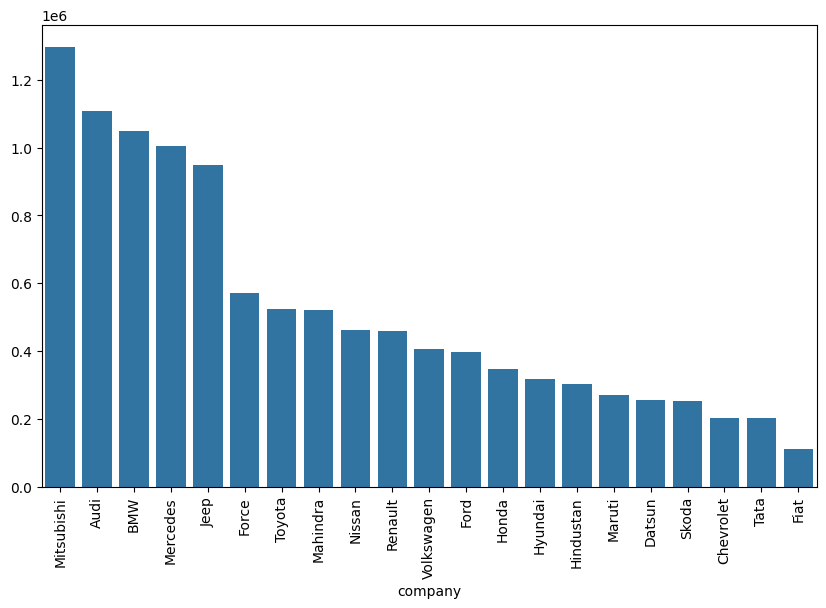

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(x=average_price_company.index, y=average_price_company.values)
plt.xticks(rotation=90)
plt.show()

In [52]:
df_encoded2 = pd.get_dummies(df['company'], prefix='company').astype(int)
df = pd.concat([df, df_encoded2], axis=1)
df = df.drop('company', axis=1)

In [53]:
df.head()

,name,year,Price,kms_driven,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol,company_Audi,company_BMW,company_Chevrolet,...,company_Mahindra,company_Maruti,company_Mercedes,company_Mitsubishi,company_Nissan,company_Renault,company_Skoda,company_Tata,company_Toyota,company_Volkswagen
0,Hyundai Santro Xing XO eRLX Euro III,2007,80000,45000,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Mahindra Jeep CL550 MDI,2006,425000,40,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,2014,325000,28000,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Ford EcoSport Titanium 1.5L TDCi,2014,575000,36000,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Ford Figo,2012,175000,41000,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
X = df.drop(['Price', 'name'], axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=1)

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=1)

rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
rf.score(X_test, y_test)

C:\Users\AMRUTA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\AMRUTA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


0.95

In [57]:
predictions = rf.predict(X_train)
predictions_df = pd.DataFrame(predictions, columns=['Predictions'])
predicted_df = pd.concat([df, predictions_df], axis=1)

In [58]:
predicted_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 849 entries, 0 to 635
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                798 non-null    object 
 1   year                798 non-null    float64
 2   Price               798 non-null    float64
 3   kms_driven          798 non-null    float64
 4   fuel_type_Diesel    798 non-null    float64
 5   fuel_type_LPG       798 non-null    float64
 6   fuel_type_Petrol    798 non-null    float64
 7   company_Audi        798 non-null    float64
 8   company_BMW         798 non-null    float64
 9   company_Chevrolet   798 non-null    float64
 10  company_Datsun      798 non-null    float64
 11  company_Fiat        798 non-null    float64
 12  company_Force       798 non-null    float64
 13  company_Ford        798 non-null    float64
 14  company_Hindustan   798 non-null    float64
 15  company_Honda       798 non-null    float64
 16  company_Hyund

In [59]:
predicted_df = predicted_df.dropna()

In [60]:
error = mean_absolute_error(predicted_df['Price'], predicted_df['Predictions'])

In [61]:
error

283604.3850085179